# Sequence Features & Forward-Looking Target

## Why this notebook exists

Our coach reviewed the Week 1/2 work and made a correct catch: `01_eda.ipynb` and `02_baseline_classifier.ipynb` treated each hourly row as an **independent classification sample** — "given this one instant, what's its label?" But this dataset is not 175,200 independent samples. It's **4 continuous per-vehicle time series**, and the dataset's own README (`data/raw/driving_pattern_diagnostics/README.md`) says so explicitly: its stated intended use cases are *"multivariate time-series forecasting"*, *"predictive maintenance modeling"*, and *"DTC forecasting and anomaly detection"* — not row-level classification.

This also matches the actual product framing better. The fleet manager persona's real question (`Capstone_Project_Plan.md` Section 1) is *"is it safe to keep driving, or do I pull it in now?"* — that is inherently a forward-looking question about what's about to happen, not a question about whether a code is already flashing right now (which barely needs a model to answer).

**What changes here, and what doesn't:**
- Same dataset, same cleaned `Fault_Label`, same fleet-manager persona, same chronological per-vehicle split methodology.
- **New:** rolling/lag features per vehicle (no look-ahead), and a new forward-looking target, `Fault_Within_6h` (and `Fault_Within_12h` as a second option) — "will a fault occur in the next N hours?" instead of "is a fault happening right now?"
- `data/raw/`, and the `Fault_Label` derivation logic in `01_eda.ipynb`, are untouched — that part of the pipeline was correct.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

SENSOR_COLS = [
    "SOC", "SOH", "Charging_Cycles", "Battery_Temp", "Motor_RPM", "Motor_Torque",
    "Motor_Temp", "Brake_Pad_Wear", "Charging_Voltage", "Tire_Pressure",
]
SEQ_SENSORS = ["Motor_RPM", "Motor_Torque", "Motor_Temp", "Battery_Temp"]
ROLL_WINDOWS = [6, 12, 24]
LAGS = [1, 3, 6]

## 1-2. Load cleaned data, sort by vehicle + time

`data/processed/driving_pattern_diagnostics_cleaned.csv` already has `Fault_Label` and `user_profile` from `01_eda.ipynb` — reused as-is, not re-derived. Sorting by `user_profile` then `timestamp` is the foundation everything below depends on: every rolling/lag/shift operation is grouped by `user_profile` specifically so a window never mixes hours from two different vehicles.

In [2]:
df = pd.read_csv(
    "../data/processed/driving_pattern_diagnostics_cleaned.csv",
    parse_dates=["timestamp"],
)
df = df.sort_values(["user_profile", "timestamp"]).reset_index(drop=True)
df["is_fault"] = df["Fault_Label"] != "Normal"

print(f"{len(df):,} rows, {df['user_profile'].nunique()} vehicles")
print(df.groupby("user_profile")["timestamp"].agg(["min", "max", "count"]))

175,200 rows, 4 vehicles
                     min                 max  count
user_profile                                       
daily_user    2020-01-01 2024-12-29 23:00:00  43800
heavy_user    2020-01-01 2024-12-29 23:00:00  43800
moderate_user 2020-01-01 2024-12-29 23:00:00  43800
rare_user     2020-01-01 2024-12-29 23:00:00  43800


## 3. Rolling / lag / delta features — per vehicle, no look-ahead

For each of the 4 sensors most tied to the Fault/Warning tiers (`Motor_RPM`, `Motor_Torque`, `Motor_Temp`, `Battery_Temp`):

- **Rolling mean/std** over trailing 6h/12h/24h windows — a trailing window *ending at and including* the current hour (the current hour's own reading is already a feature on its own via the original 10 sensor columns, so including it in "recent history as of now" is not look-ahead; the window never includes anything after the current row).
- **Lag features** — value 1h/3h/6h ago.
- **Delta** — current value minus value 6h ago (a simple trend indicator).

Every one of these is computed via `groupby("user_profile")`, so a window for one vehicle can never pull in another vehicle's hours — confirmed with an explicit check after building the features.

In [3]:
seq_feature_cols = []

for col in SEQ_SENSORS:
    grouped = df.groupby("user_profile")[col]

    for w in ROLL_WINDOWS:
        mean_col, std_col = f"{col}_roll_mean_{w}h", f"{col}_roll_std_{w}h"
        df[mean_col] = grouped.transform(lambda s, w=w: s.rolling(window=w, min_periods=w).mean())
        df[std_col] = grouped.transform(lambda s, w=w: s.rolling(window=w, min_periods=w).std())
        seq_feature_cols += [mean_col, std_col]

    for lag in LAGS:
        lag_col = f"{col}_lag_{lag}h"
        df[lag_col] = grouped.shift(lag)
        seq_feature_cols.append(lag_col)

    delta_col = f"{col}_delta_6h"
    df[delta_col] = df[col] - grouped.shift(6)
    seq_feature_cols.append(delta_col)

print(f"Added {len(seq_feature_cols)} sequence features:")
print(seq_feature_cols)

Added 40 sequence features:
['Motor_RPM_roll_mean_6h', 'Motor_RPM_roll_std_6h', 'Motor_RPM_roll_mean_12h', 'Motor_RPM_roll_std_12h', 'Motor_RPM_roll_mean_24h', 'Motor_RPM_roll_std_24h', 'Motor_RPM_lag_1h', 'Motor_RPM_lag_3h', 'Motor_RPM_lag_6h', 'Motor_RPM_delta_6h', 'Motor_Torque_roll_mean_6h', 'Motor_Torque_roll_std_6h', 'Motor_Torque_roll_mean_12h', 'Motor_Torque_roll_std_12h', 'Motor_Torque_roll_mean_24h', 'Motor_Torque_roll_std_24h', 'Motor_Torque_lag_1h', 'Motor_Torque_lag_3h', 'Motor_Torque_lag_6h', 'Motor_Torque_delta_6h', 'Motor_Temp_roll_mean_6h', 'Motor_Temp_roll_std_6h', 'Motor_Temp_roll_mean_12h', 'Motor_Temp_roll_std_12h', 'Motor_Temp_roll_mean_24h', 'Motor_Temp_roll_std_24h', 'Motor_Temp_lag_1h', 'Motor_Temp_lag_3h', 'Motor_Temp_lag_6h', 'Motor_Temp_delta_6h', 'Battery_Temp_roll_mean_6h', 'Battery_Temp_roll_std_6h', 'Battery_Temp_roll_mean_12h', 'Battery_Temp_roll_std_12h', 'Battery_Temp_roll_mean_24h', 'Battery_Temp_roll_std_24h', 'Battery_Temp_lag_1h', 'Battery_Temp_la

In [4]:
# Sanity check: confirm no cross-vehicle bleed. Each vehicle's first `lag`/`window-1` rows
# should be NaN (no history yet) — if a window pulled in the previous vehicle's tail instead,
# these would be non-null.
check = df.groupby("user_profile").head(24)[["user_profile", "timestamp", "Motor_RPM_roll_mean_24h", "Motor_RPM_lag_6h"]]
first_rows_per_vehicle = df.groupby("user_profile").apply(lambda g: g.iloc[[0, 5, 23]], include_groups=False)
print("First/6th/24th row per vehicle — roll_mean_24h and lag_6h should be NaN until enough history exists:")
print(first_rows_per_vehicle[["timestamp", "Motor_RPM_roll_mean_24h", "Motor_RPM_lag_6h"]])

First/6th/24th row per vehicle — roll_mean_24h and lag_6h should be NaN until enough history exists:
                               timestamp  Motor_RPM_roll_mean_24h  \
user_profile                                                        
daily_user    0      2020-01-01 00:00:00                      NaN   
              5      2020-01-01 05:00:00                      NaN   
              23     2020-01-01 23:00:00               441.275386   
heavy_user    43800  2020-01-01 00:00:00                      NaN   
              43805  2020-01-01 05:00:00                      NaN   
              43823  2020-01-01 23:00:00              1121.029370   
moderate_user 87600  2020-01-01 00:00:00                      NaN   
              87605  2020-01-01 05:00:00                      NaN   
              87623  2020-01-01 23:00:00               498.282102   
rare_user     131400 2020-01-01 00:00:00                      NaN   
              131405 2020-01-01 05:00:00                      NaN   
  

## 4. Forward-looking target: `Fault_Within_Nh`

For each row at time *t* (within one vehicle), `True` if `is_fault` is `True` for **any** of the next *N* hours — *t+1* through *t+N* — **excluding** *t* itself (this is a forecast of what's about to happen, not a restatement of what's happening now). Implemented by reversing each vehicle's series, shifting by 1 (so the current position no longer includes itself), taking a trailing max over the next `N` positions in reversed order (= the next `N` hours in real time), then reversing back — verified below with a hand-checkable example before trusting it on the full dataset.

In [5]:
def fault_within_next_n_hours(is_fault_series, n):
    """True if any of the next n rows (strictly after the current one) is a fault.
    NaN where fewer than n future rows exist (handled by min_periods=n)."""
    reversed_series = is_fault_series[::-1]
    excludes_current = reversed_series.shift(1)  # "next in original time" once reversed
    forward_max = excludes_current.rolling(window=n, min_periods=n).max()
    return forward_max[::-1]


# Hand-checkable example before trusting this on 175k rows — cross-checked against a plain
# brute-force loop (look at demo[i+1:i+1+n]) to make sure the vectorized version is right,
# not just asserted to be right.
demo = pd.Series([0, 0, 1, 0, 0, 0, 1, 0], name="is_fault")
demo_result = fault_within_next_n_hours(demo, n=3)
brute_force = [
    (float(demo[i + 1 : i + 1 + 3].max()) if len(demo[i + 1 : i + 1 + 3]) == 3 else np.nan)
    for i in range(len(demo))
]
print("Demo is_fault:  ", demo.tolist())
print("Fault_Within_3h:", demo_result.tolist())
print("Brute-force:    ", brute_force)
assert all((pd.isna(a) and pd.isna(b)) or a == b for a, b in zip(demo_result, brute_force)), "mismatch!"
print("Match confirmed.")

Demo is_fault:   [0, 0, 1, 0, 0, 0, 1, 0]
Fault_Within_3h: [1.0, 1.0, 0.0, 1.0, 1.0, nan, nan, nan]
Brute-force:     [1.0, 1.0, 0.0, 1.0, 1.0, nan, nan, nan]
Match confirmed.


In [6]:
for n in [6, 12]:
    col = f"Fault_Within_{n}h"
    df[col] = df.groupby("user_profile")["is_fault"].transform(
        lambda s, n=n: fault_within_next_n_hours(s, n)
    )

print("Rows with a defined (non-NaN) forward-looking target, per window:")
print(df[["Fault_Within_6h", "Fault_Within_12h"]].notna().sum())
print()
print("Class balance — Fault_Within_6h (rows with a defined target only):")
print(df["Fault_Within_6h"].dropna().value_counts(normalize=True).mul(100).round(3))
print()
print("Class balance — Fault_Within_12h (rows with a defined target only):")
print(df["Fault_Within_12h"].dropna().value_counts(normalize=True).mul(100).round(3))
print()
print("For comparison, the original instant-level Fault_Label imbalance was Fault 1.51% + Warning 0.12% = 1.63% any-issue.")

Rows with a defined (non-NaN) forward-looking target, per window:
Fault_Within_6h     175176
Fault_Within_12h    175152
dtype: int64

Class balance — Fault_Within_6h (rows with a defined target only):
Fault_Within_6h
0.0    90.949
1.0     9.051
Name: proportion, dtype: float64

Class balance — Fault_Within_12h (rows with a defined target only):
Fault_Within_12h
0.0    82.854
1.0    17.146
Name: proportion, dtype: float64

For comparison, the original instant-level Fault_Label imbalance was Fault 1.51% + Warning 0.12% = 1.63% any-issue.


## 5. Drop rows with an incomplete window — don't mislabel them

Two edge cases produce `NaN`, and both get dropped rather than filled or guessed:
- **Start of each vehicle's timeline** (first 24h): the rolling/lag features don't have enough history yet.
- **End of each vehicle's timeline** (last 6h/12h): there aren't enough *future* hours left to know whether `Fault_Within_Nh` is true or false.

This drops a small, known number of rows per vehicle (24 at the start + up to 12 at the end, out of 43,800 rows per vehicle) — negligible relative to the dataset, and far preferable to labeling an incomplete window as `False` by default, which would quietly bias the target toward "no fault" right at the one place the data can't actually support that claim.

In [7]:
before = len(df)

# Cold-start rows (incomplete rolling/lag history) — same for every target, drop once, globally.
feature_na_mask = df[seq_feature_cols].isna().any(axis=1)
print(f"Dropping {feature_na_mask.sum()} cold-start rows (incomplete rolling/lag window) "
      f"— {feature_na_mask.sum() / 4:.0f} per vehicle, as expected for a 24h max window.")
df = df.loc[~feature_na_mask].reset_index(drop=True)

# End-of-timeline rows are target-specific (6h target loses 6 rows/vehicle at the tail, 12h
# loses 12) — reported here, but NOT dropped globally, since a row missing only the 12h target
# can still be valid training data for the 6h target. Each downstream notebook drops NaNs for
# whichever target column it actually trains on.
for n in [6, 12]:
    col = f"Fault_Within_{n}h"
    missing = df[col].isna().sum()
    print(f"{col}: {missing} rows ({missing / 4:.0f}/vehicle) lack a full future window — "
          f"will be dropped by whichever notebook trains on this specific target.")

print(f"\n{before:,} rows -> {len(df):,} rows after dropping cold-start rows "
      f"({before - len(df)} dropped, {(before - len(df)) / before * 100:.3f}%).")

Dropping 92 cold-start rows (incomplete rolling/lag window) — 23 per vehicle, as expected for a 24h max window.


Fault_Within_6h: 24 rows (6/vehicle) lack a full future window — will be dropped by whichever notebook trains on this specific target.
Fault_Within_12h: 48 rows (12/vehicle) lack a full future window — will be dropped by whichever notebook trains on this specific target.

175,200 rows -> 175,108 rows after dropping cold-start rows (92 dropped, 0.053%).


## 6. Feature relevance against the new target — same split, same method, compare rankings

Reusing the exact chronological per-vehicle split from `02_baseline_classifier.ipynb` (last ~20% of each vehicle's own timeline as test) and the same train-fold-only `mutual_info_classif` methodology from Week 1/2 — only the target and feature set have changed. Primary target for this comparison: `Fault_Within_6h`.

Train: 140,064 rows, Test: 35,020 rows
Fault_Within_6h rate — train: 8.971%, test: 9.395%

Top 15 features by mutual information with Fault_Within_6h:
Motor_RPM_roll_mean_24h       0.102345
Motor_Torque_roll_mean_24h    0.101505
Motor_Torque_roll_std_24h     0.099231
Motor_RPM_roll_std_24h        0.099230
Brake_Pad_Wear                0.096273
SOC                           0.088216
SOH                           0.087745
Motor_Torque_roll_mean_12h    0.063431
Motor_RPM_roll_mean_12h       0.062768
Motor_RPM_roll_std_12h        0.062452
Motor_Torque_roll_std_12h     0.062265
Motor_RPM_roll_mean_6h        0.040086
Motor_Torque_roll_mean_6h     0.039790
Motor_Torque_roll_std_6h      0.039043
Motor_RPM_roll_std_6h         0.038545
dtype: float64


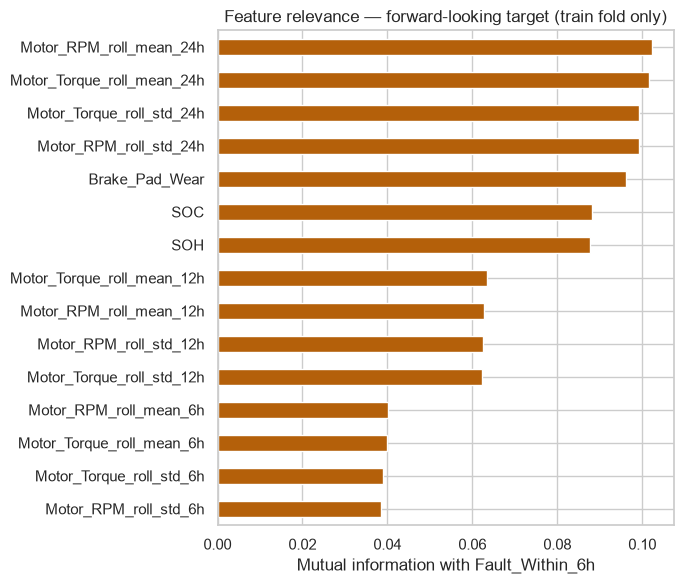

In [8]:
def chronological_split(data, group_col="user_profile", time_col="timestamp", test_frac=0.2):
    train_parts, test_parts = [], []
    for _, g in data.groupby(group_col):
        g = g.sort_values(time_col)
        cutoff = int(len(g) * (1 - test_frac))
        train_parts.append(g.iloc[:cutoff])
        test_parts.append(g.iloc[cutoff:])
    return pd.concat(train_parts).reset_index(drop=True), pd.concat(test_parts).reset_index(drop=True)


TARGET = "Fault_Within_6h"
model_df = df.dropna(subset=[TARGET]).copy()
model_df[TARGET] = model_df[TARGET].astype(bool)

train_df, test_df = chronological_split(model_df)
ALL_FEATURE_COLS = SENSOR_COLS + seq_feature_cols

mi_scores = mutual_info_classif(train_df[ALL_FEATURE_COLS], train_df[TARGET], random_state=42)
mi_ranking = pd.Series(mi_scores, index=ALL_FEATURE_COLS).sort_values(ascending=False)

print(f"Train: {len(train_df):,} rows, Test: {len(test_df):,} rows")
print(f"{TARGET} rate — train: {train_df[TARGET].mean()*100:.3f}%, test: {test_df[TARGET].mean()*100:.3f}%")
print()
print("Top 15 features by mutual information with Fault_Within_6h:")
print(mi_ranking.head(15))

mi_ranking.head(15).plot(kind="barh", figsize=(7, 6), color="#B4600A")
plt.gca().invert_yaxis()
plt.xlabel("Mutual information with Fault_Within_6h")
plt.title("Feature relevance — forward-looking target (train fold only)")
plt.tight_layout()
plt.show()

### Comparing to the original instant-level ranking — what changed, and a confound to flag

Original ranking (from `02_baseline_classifier.ipynb`, target = instant `Fault_Label`, 10 raw sensor columns only):

```
Motor_RPM            0.069     Motor_Temp        0.0085
Motor_Torque         0.069     Tire_Pressure     0.0076
Charging_Voltage     0.017     Brake_Pad_Wear    0.0050
Battery_Temp         0.011     SOC               0.0040
                               SOH               0.0000
                               Charging_Cycles   0.0000
```

The rolling-window features dominating the new ranking is expected — that's the whole point of adding them. But two of the original *raw* columns jump dramatically too: `Brake_Pad_Wear` (0.005 → 0.096, ~19x) and `SOH` (≈0 → 0.088, from literally uninformative to top-7). Neither has an obvious causal link to `Fault_Within_6h` under the labeling rule (`Brake_Pad_Wear` isn't part of any DTC-to-tier mapping at all; `SOH` maps only loosely via `P0S`). The more likely explanation: both increase monotonically with vehicle usage/age, and usage intensity is also what drives the fault rate (heavy_user: 2.57% vs. rare_user: 0.99%, from the original EDA) — so mutual information here may partly be picking up **"which vehicle is this," a confound, not a genuine per-vehicle predictive relationship.** This is exactly the kind of thing worth stress-testing the same way the near-perfect baseline score was stress-tested in `02_baseline_classifier.ipynb` — flagged here for the retraining notebook to check with per-class/per-vehicle permutation importance, not assumed to be real signal.

## 7. Save the engineered dataset

Includes the original columns, all 40 rolling/lag/delta features, and both `Fault_Within_6h`/`Fault_Within_12h` target columns (with their own independent NaN tails) — `03_sequence_classifier.ipynb` picks a target and drops that column's remaining NaNs at training time.

In [9]:
out_path = "../data/processed/driving_pattern_diagnostics_sequence_features.csv"
df.to_csv(out_path, index=False)
print(f"Saved {len(df):,} rows x {len(df.columns)} columns to {out_path}")

Saved 175,108 rows x 58 columns to ../data/processed/driving_pattern_diagnostics_sequence_features.csv


## Summary

- Reframed the task per the coach's feedback: from "classify this instant" to "predict a fault in the next N hours," matching the dataset's own stated intended use (`data/raw/driving_pattern_diagnostics/README.md`: *"multivariate time-series forecasting"*, *"DTC forecasting and anomaly detection"*) and the fleet-manager persona's actual question.
- Added 40 rolling/lag/delta features (6h/12h/24h windows, 1h/3h/6h lags, 6h delta) for `Motor_RPM`, `Motor_Torque`, `Motor_Temp`, `Battery_Temp` — all computed per-vehicle (`groupby("user_profile")`), verified with an explicit no-cross-vehicle-bleed check.
- Built `Fault_Within_6h` and `Fault_Within_12h` — verified against a hand-checked, brute-force-cross-checked helper function before trusting it on the full dataset. Class balance: **9.05% positive at 6h, 17.15% at 12h** — both meaningfully less extreme than the original 1.63% instant-level rate, as expected.
- Dropped 92 cold-start rows (23/vehicle, incomplete 24h history) globally; target-specific end-of-timeline rows (24 for 6h, 48 for 12h) are left as NaN in their own column for the training notebook to drop.
- Feature relevance re-run on the new target (train fold only, same chronological per-vehicle split): rolling-window features dominate as expected, but `Brake_Pad_Wear` and `SOH` also jumped from near-zero to top-7 relevance — flagged as a likely **vehicle-identity confound** (both track usage intensity, which also drives fault rate) rather than assumed to be genuine signal, to be checked with permutation importance in the next notebook.
- Saved to `data/processed/driving_pattern_diagnostics_sequence_features.csv` for `03_sequence_classifier.ipynb`.

**Next:** retrain Random Forest + XGBoost on `Fault_Within_6h` with this feature set, using the identical split/class-weight/evaluation methodology as `02_baseline_classifier.ipynb`, and compare directly against the original 1.000/0.985 row-level results.